In [34]:
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_val_score
import optuna
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
import joblib
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [35]:


# Download latest version
path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

print("Path to competition files:", path)

Path to competition files: /home/vitaliy/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques


In [36]:
url_train ='/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/assets/train.csv'
url_test = '/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/assets/test.csv'
url_sample = '/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/assets/sample_submission.csv'
dftr = pd.read_csv(url_train)
dftt = pd.read_csv(url_test)
dfsm = pd.read_csv(url_sample)
dftr

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,

In [37]:

dftr.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

<function matplotlib.pyplot.show(close=None, block=None)>

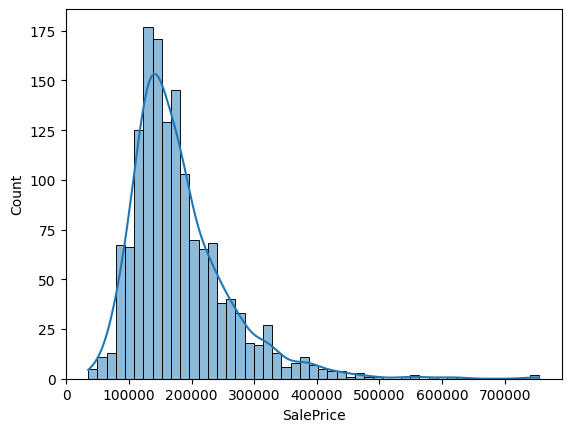

In [38]:
sns.histplot(dftr['SalePrice'], kde=True)
plt.show


Normal SalePrice and Log SalePrice +1

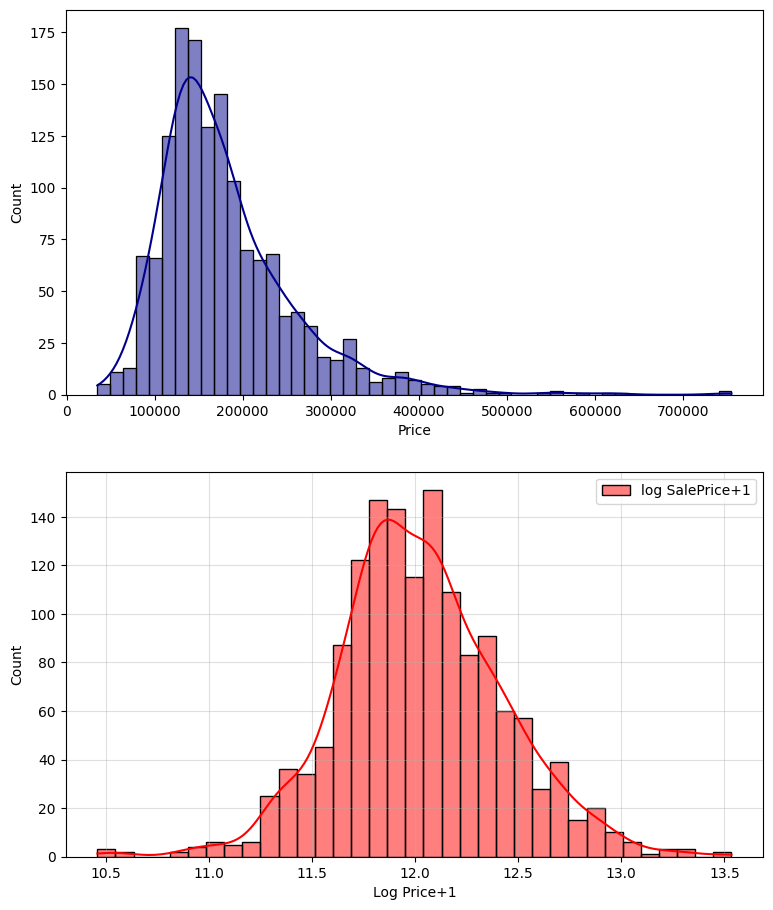

In [39]:
fig, axes = plt.subplots (2, 1, figsize=(9,11))

sns.histplot(dftr['SalePrice'], kde=True, ax=axes[0], label='SalePrice', color="darkblue")
axes[0].set_xlabel('Price')
sns.histplot(np.log1p(dftr['SalePrice']),kde=True, ax=axes[1], label='log SalePrice+1', color='red')
axes[1].set_xlabel('Log Price+1')

plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

Relationship beetwen Live Area and Price

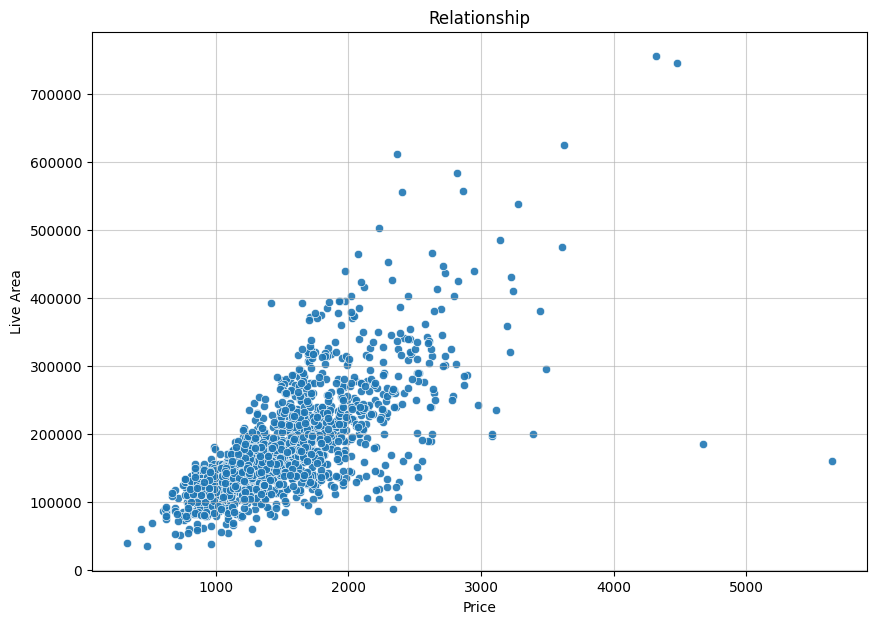

In [40]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=dftr, x='GrLivArea', y='SalePrice', alpha=0.9)

plt.xlabel('Price')
plt.ylabel('Live Area')
plt.title('Relationship')
plt.grid(True, alpha=0.6)
plt.show()


In [41]:
dftr.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [42]:
pd.set_option('display.max_columns', None)
dftr


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,

Show all NaN by percent

In [43]:
nans = dftr.isnull().sum()
percentage = (dftr.isnull().sum() / dftr.shape[0]) * 100
table = pd.concat([nans, percentage], axis=1, keys=['allNan','percentage'])
all_nan = table[table['allNan'] > 0].sort_values(by='allNan', ascending=False)
all_nan

,allNan,percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


Target, Log Target, new data frame, update 'GrLivArea' column.

In [44]:
dftr = dftr[dftr['GrLivArea'] < 4000]


y_train_tg = dftr['SalePrice']
y_train_log = np.log1p(dftr['SalePrice'])


X_train_raw = dftr.drop(['Id','SalePrice'], axis=1)
X_test_raw = dftt.drop(['Id'], axis=1)

df = pd.concat([X_train_raw, X_test_raw], axis=0, ignore_index=False)
df


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,NaN,0.0,TA,TA,PConc,Gd,TA,Av,GLQ,337.0,Unf,0.0,

Numeric Correlation


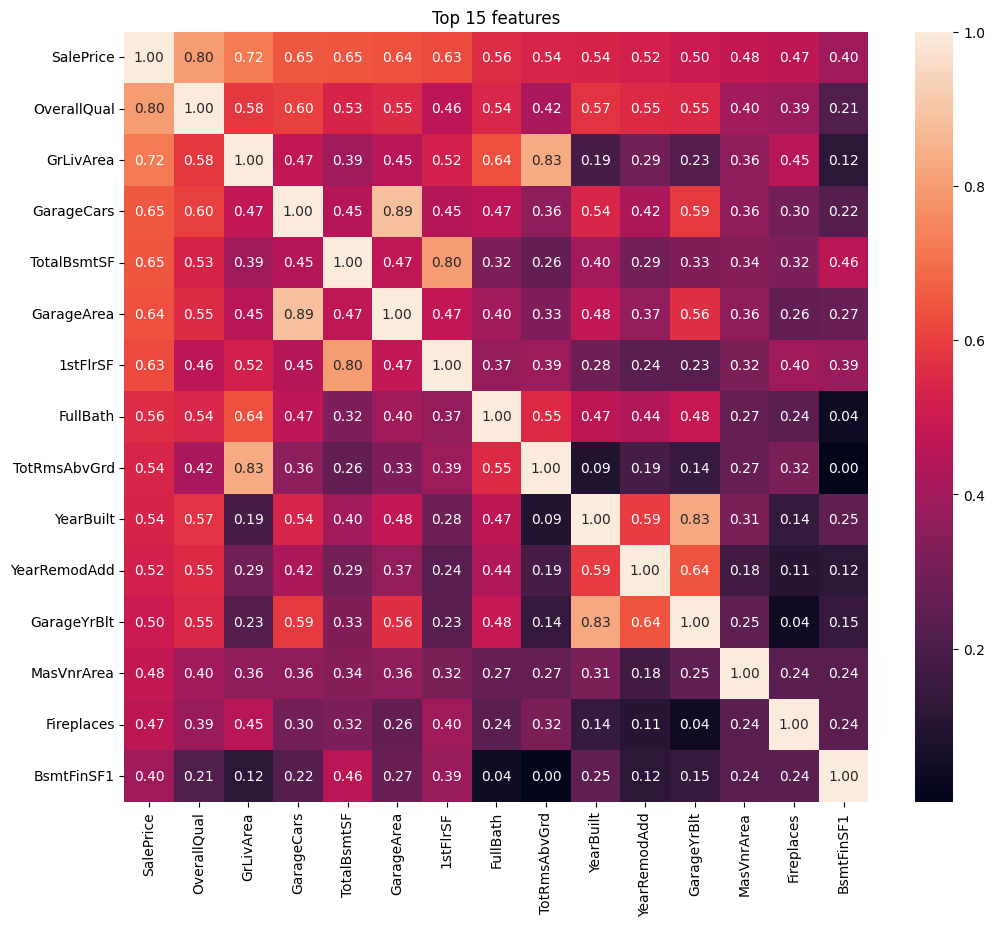

In [45]:
plt.figure(figsize=(12,10))
num_train = dftr.select_dtypes(include=[np.number]).drop(['Id'], axis=1)
top_15 = num_train.corr().nlargest(15, 'SalePrice')['SalePrice'].index
cm = num_train[top_15].corr()
sns.heatmap(cm, annot=True, fmt='.2f')
plt.title('Top 15 features')
plt.show()

PipeLine,
Separate data types,
fill zero,
fill median.

In [46]:
all_nums = df.select_dtypes(include=[np.number]).columns.tolist()
all_cats = df.select_dtypes(include=['object']).columns.tolist()

cats_none = [
    'PoolQC','MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
    'GarageType', 'GarageFinish','GarageQual', 'GarageCond',
    'BsmtFinType1','BsmtFinType2', 'BsmtExposure',
    'BsmtCond', 'BsmtQual', 'MasVnrType',
]

cats_other = list(set(all_cats) - set(cats_none))

nums_zero = ['GarageArea', 'GarageCars', 'BsmtFinSF1','BsmtFinSF2',
             'BsmtUnfSF', 'TotalBsmtSF','MasVnrArea']
nums_median = list(set(all_nums) - set(nums_zero))

zero_trans = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='constant', fill_value=0))])

median_trans = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

cat_none_trans = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
        ('onehotencode', OneHotEncoder(handle_unknown='ignore',sparse_output=False))


    ]
    )

cat_freq_trans = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehotencoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))

    ]
)

preprocessor= ColumnTransformer(
    transformers=[
        ('num_zero', zero_trans,nums_zero),
        ('num_median', median_trans, nums_median,),
        ('cat_none', cat_none_trans, cats_none),
        ('cat_freq', cat_freq_trans, cats_other)
    ]
)

/tmp/ipykernel_166056/4076104840.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  all_cats = df.select_dtypes(include=['object']).columns.tolist()


Split Train and Test
made BaseLine

In [64]:
train_orig = len(X_train_raw)

X_train_split = df.iloc[:train_orig]
X_test_split = df.iloc[train_orig:]

print(f'Recovery Size of train: {X_train_split.shape}')
print(f'Recovery Size of test: {X_test_split.shape}')

Recovery Size of train: (1456, 75)
Recovery Size of test: (1459, 75)


In [48]:
baseline_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),('model', Ridge(alpha=1.0))
    ]
)

baseline_pipeline.fit(X_train_split,y_train_log)

pred_log = baseline_pipeline.predict(X_test_split) 

# pred_final = np.expm1(pred_log)
# print(pred_final)

In [49]:

baseline_scores = cross_val_score(
    baseline_pipeline,
    X_train_split,
    y_train_log,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)


baseline_rmsle_cv = -baseline_scores.mean()

print(f" RMSLE baseline : {baseline_rmsle_cv:.5f}")


 RMSLE baseline : 0.12010


In [50]:
url_train ='/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/assets/train.csv'
url_test = '/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/assets/test.csv'
url_sample = '/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/assets/sample_submission.csv'
dftr = pd.read_csv(url_train)
dftt = pd.read_csv(url_test)
dfsm = pd.read_csv(url_sample)

In [51]:
test_id = dftt['Id']
dftr = dftr[dftr['GrLivArea'] < 4000]

y_train_log = np.log1p(dftr['SalePrice'])


X_train_raw = dftr.copy()
X_test_raw = dftt.copy()

col_drop = ['Id', 'PoolQC', 'MiscFeature', 'Alley', 'Fence']
X_train_raw = dftr.drop(col_drop + ['SalePrice'], axis=1)
X_test_raw = dftt.drop(col_drop, axis=1)

df = pd.concat([X_train_raw, X_test_raw], axis=0, ignore_index=True)
df.shape


(2915, 75)

Total square Feet, Total Bath,

In [52]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

df['TotalBath'] = (df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath']))

df['HouseAge'] = df['YrSold'] - df['YearRemodAdd']

df['AreaPerRoom'] = df['GrLivArea'] / (df['TotRmsAbvGrd'] + 1e-5)

df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
df['hasFirePlace'] = (df['Fireplaces'] > 0).astype(int)

df.shape

cols_to_drop = ['1stFlrSF', '2ndFlrSF', 'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', 'TotRmsAbvGrd']

df = df.drop(cols_to_drop, axis=1)
df.shape

(2915, 75)

In [53]:
# if 'GarageCars' in df.columns:
#     df = df.drop(['GarageCars'], axis=1)

# if 'TotRmsAbvGrd' in df.columns:
#     df = df.drop(['TotRmsAbvGrd'], axis=1)

# if '1stFlrSF' in df.columns:
#     df=df.drop(['1stFlrSF'], axis=1)
    

In [54]:
all_nums = df.select_dtypes(include=[np.number]).columns.tolist()
all_cats = df.select_dtypes(include=['object']).columns.tolist()

cats_none = [
    'FireplaceQu', 
    'GarageType', 'GarageFinish','GarageQual', 'GarageCond',
    'BsmtFinType1','BsmtFinType2', 'BsmtExposure',
    'BsmtCond', 'BsmtQual', 'MasVnrType',
]

cats_other = list(set(all_cats) - set(cats_none))

nums_zero = ['GarageArea', 'GarageCars','TotalBsmtSF','MasVnrArea']
nums_median = list(set(all_nums) - set(nums_zero))

zero_trans = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='constant', fill_value=0))])

median_trans = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

cat_none_trans = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
        ('onehotencode', OneHotEncoder(handle_unknown='ignore',sparse_output=False))


    ]
    )

cat_freq_trans = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehotencoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))

    ]
)

preprocessor= ColumnTransformer(
    transformers=[
        ('num_zero', zero_trans,nums_zero),
        ('num_median', median_trans, nums_median,),
        ('cat_none', cat_none_trans, cats_none),
        ('cat_freq', cat_freq_trans, cats_other)
    ]
)

/tmp/ipykernel_166056/1529531299.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  all_cats = df.select_dtypes(include=['object']).columns.tolist()


In [55]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

train_size = len(y_train_log)

X_train_split = df.iloc[:train_size]
X_test_split = df.iloc[train_size:]

print(X_train_split)
print(X_test_split)

      MSSubClass MSZoning  LotFrontage  LotArea Street LotShape LandContour  \
0             60       RL         65.0     8450   Pave      Reg         Lvl   
1             20       RL         80.0     9600   Pave      Reg         Lvl   
2             60       RL         68.0    11250   Pave      IR1         Lvl   
3             70       RL         60.0     9550   Pave      IR1         Lvl   
4             60       RL         84.0    14260   Pave      IR1         Lvl   
...          ...      ...          ...      ...    ...      ...         ...   
1451          60       RL         62.0     7917   Pave      Reg         Lvl   
1452          20       RL         85.0    13175   Pave      Reg         Lvl   
1453          70       RL         66.0     9042   Pave      Reg         Lvl   
1454          20       RL         68.0     9717   Pave      Reg         Lvl   
1455          20       RL         75.0     9937   Pave      Reg         Lvl   

     Utilities LotConfig LandSlope Neighborhood Con

In [56]:
def objective(trial):
    alpha_param = trial.suggest_float('alpha', 1e-3, 1e3, log=True)

    tuned_pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', Ridge(alpha=alpha_param, random_state=42 ))
        ]
    )

    scores = cross_val_score(
        tuned_pipeline,
        X_train_split,
        y_train_log,
        cv=5,
        scoring = 'neg_root_mean_squared_error',
        n_jobs=-1
    )
    return -scores.mean()
study =  optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, n_jobs=-1)
print(f'new RSMLE:  {study.best_value:.5f}')
print(f'optimal param:  {study.best_params['alpha']:.4f}')


best_alpha = study.best_params['alpha']
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=best_alpha, random_state=42))

])

final_pipeline.fit(X_train_split, y_train_log)

ridge_pred_log = final_pipeline.predict(X_test_split)
final_pred = np.expm1(ridge_pred_log)

dfsm['SalePrice'] = final_pred
dfsm.to_csv('submission_optuna.csv', index=False)

/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/env/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


new RSMLE:  0.11420
optimal param:  12.9965


In [57]:
num_col = df.select_dtypes(include=[np.number]).columns.tolist()

corr_mat = df[num_col].corr().abs()

print(corr_mat)
upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))

high_corr = []

for col in upper_tri:
    high_corr_feat = upper_tri.index[upper_tri[col] > 0.8].tolist()
    for feature in high_corr_feat:
        coef = upper_tri.loc[feature,col]
        high_corr.append((feature,col,coef))
        print( feature, col,  coef)

if not high_corr:
    print('critical duplicates not detect')

               MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  \
MSSubClass       1.000000     0.429710  0.204256     0.033559     0.065610   
LotFrontage      0.429710     1.000000  0.468266     0.204049     0.074229   
LotArea          0.204256     0.468266  1.000000     0.089867     0.034224   
OverallQual      0.033559     0.204049  0.089867     1.000000     0.093280   
OverallCond      0.065610     0.074229  0.034224     0.093280     1.000000   
YearBuilt        0.034342     0.118095  0.019426     0.597370     0.368336   
YearRemodAdd     0.043261     0.086951  0.017290     0.571681     0.048112   
MasVnrArea       0.005198     0.206062  0.111306     0.427549     0.137122   
BsmtFinSF1       0.066710     0.169874  0.166731     0.270701     0.048810   
BsmtFinSF2       0.072507     0.051036  0.086287     0.041879     0.041397   
BsmtUnfSF        0.126056     0.117833  0.020819     0.275880     0.138414   
TotalBsmtSF      0.227348     0.314275  0.228183     0.547289   

LGBM Regression


In [58]:

train_size = len(y_train_log)
df_processed = preprocessor.fit_transform(df)

X_train_ready = df_processed[:train_size]
X_test_ready = df_processed[train_size:]

def objective (trial):
    params ={
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 80),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5,100),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    model = LGBMRegressor(**params)

    scores = cross_val_score(
        model,
        X_train_ready,
        y_train_log,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(f'best RMSLE boosting: {study.best_value:.5f}')

best_model = LGBMRegressor(**study.best_params, random_state=42, n_jobs=-1, verbose=-1)
best_model.fit(X_train_ready, y_train_log)

lgbm_pred_log = best_model.predict(X_test_ready)
final_preds = np.expm1(lgbm_pred_log)





/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/en

best RMSLE boosting: 0.11808


/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [59]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
    }

    model = XGBRegressor(**params)
    scores = cross_val_score(
        model,
        X_train_ready,
        y_train_log,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    return -scores.mean()


study_xgb = optuna.create_study(direction="minimize")

study_xgb.optimize(objective_xgb, n_trials=20, n_jobs=-1)
print(f"RMSLE  XGBoost: {study_xgb.best_value:.5f}")


model_xgb = XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)
model_xgb.fit(X_train_ready, y_train_log)



/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/env/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RMSLE  XGBoost: 0.11775


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7390950028241461
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [60]:
def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "random_seed": 42,
        "verbose": 0,  
        "thread_count": -1,
    }

    model = CatBoostRegressor(**params)
    scores = cross_val_score(
        model,
        X_train_ready,
        y_train_log,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    return -scores.mean()


study_cat = optuna.create_study(direction="minimize")

study_cat.optimize(objective_cat, n_trials=15, n_jobs=-1)
print(f" RMSLE  CatBoost: {study_cat.best_value:.5f}")

model_cat = CatBoostRegressor(**study_cat.best_params, random_seed=42, verbose=0, thread_count=-1)
model_cat.fit(X_train_ready, y_train_log)

 RMSLE  CatBoost: 0.11264


CatBoostRegressor(depth=4, iterations=821, l2_leaf_reg=4.264074012476512, learning_rate=0.08214943086244601, loss_function='RMSE', random_seed=42, verbose=0)

In [61]:

final_pipeline.fit(X_train_split, y_train_log)
X_test_ready_lgbm = preprocessor.transform(X_test_split)
ridge_pred_log = final_pipeline.predict(X_test_split)


ridge_pred_log = final_pipeline.predict(X_test_split)
lgbm_pred_log = best_model.predict(X_test_ready_lgbm)

pred_xgb_log = model_xgb.predict(X_test_ready)
pred_cat_log = model_cat.predict(X_test_ready)


ensemble_pred_log = (0.15 * ridge_pred_log) + (0.3 * lgbm_pred_log) + (0.2 * pred_xgb_log) + (0.35 * pred_cat_log)
ensemble_pred = np.expm1(ensemble_pred_log)

dfsm['SalePrice'] = ensemble_pred
dfsm.to_csv('submission_ensemble.csv', index=False)

/home/vitaliy/Desktop/elbrus bootcamp/phase 1/project/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [63]:
os.makedirs("models", exist_ok=True)

joblib.dump(preprocessor, 'models/preprocessor.joblib')

joblib.dump(final_pipeline.named_steps['model'], 'models/ridge_model.joblib')

joblib.dump(best_model, 'models/lgbm_model.joblib')

joblib.dump(model_xgb, "models/xgb_model.joblib")

joblib.dump(model_cat, "models/cat_model.joblib")

print('all artefacts succuses export to folder models')

all artefacts succuses export to folder models
